<a href="https://colab.research.google.com/github/anushree124/Swift_Assignment/blob/main/Anushree_Swift_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandasql # install the library using pip

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=a79aaac995ed8a4c60f1f6d5412f6b5a2c6e8c1a6553107c96e8fac5576c505c
  Stored in directory: /root/.cache/pip/wheels/68/5d/a5/edc271b998f909801d7956959f699b976cc9896075dc47c153
Successfully built pandasql


In [16]:
# =============================================
# INITIAL SETUP (Run This First)
# =============================================
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandasql import sqldf
from scipy import stats
import io
import warnings
warnings.filterwarnings('ignore')

# Install required packages
!pip install pandasql
!pip install seaborn --upgrade

# Style setup - using default styles that exist in Colab
plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

# =============================================
# DATA UPLOAD (Run This Second)
# =============================================
def upload_files():
    """Handles file uploads for Colab environment"""
    uploaded = files.upload()
    data = {}

    if 'sales_data.csv' in uploaded:
        data['sales'] = pd.read_csv(io.BytesIO(uploaded['sales_data.csv']))
    else:
        print("⚠️ sales_data.csv not found - using sample data")
        data['sales'] = pd.DataFrame([
            ['B12020KBUI', '2019-05-18', '1000 Inputs', '1002 Mice', 0, 0, 0],
            ['B12020KBUI', '2019-05-19', '1000 Inputs', '1002 Mice', 0, 0, 0],
            ['D12125XVGK', '2019-08-17', '1000 Inputs', '1002 Mice', 49.95, 1, 0],
            ['C02228YPPT', '2019-06-24', '1000 Inputs', '1004 Computer Headsets and Mics', 8.5, 1, 0],
            ['B1212:PZ:V', '2019-05-01', '1000 Inputs', '1006 Gamepads and Controllers', 525.84, 16, 8.13],
            ['B1212:PZ:V', '2019-05-02', '1000 Inputs', '1006 Gamepads and Controllers', 395.88, 12, 0.21],
            ['C120[H:8NV', '2019-07-15', '2000 Electronics', '2005 Audio', 299.99, 5, 0],
            ['C120[H:8NV', '2019-07-16', '2000 Electronics', '2005 Audio', 249.99, 8, 0],
            ['C120[H:8NV', '2019-07-17', '2000 Electronics', '2005 Audio', 249.99, 6, 0]
        ], columns=['SKU_NAME', 'FEED_DATE', 'CATEGORY', 'SUB_CATEGORY', 'ORDERED_REVENUE', 'ORDERED_UNITS', 'REP_OOS'])

    if 'glance_data.csv' in uploaded:
        data['glance'] = pd.read_csv(io.BytesIO(uploaded['glance_data.csv']))
    else:
        print("⚠️ glance_data.csv not found - using sample data")
        data['glance'] = pd.DataFrame([
            ['B1212:PZ:V', '2019-05-01', 455, 16],
            ['B1212:PZ:V', '2019-05-02', 478, 12],
            ['B1212:PZ:V', '2019-05-03', 681, 42],
            ['B1212:PZ:V', '2019-05-04', 662, 70],
            ['C120[H:8NV', '2019-07-15', 1200, 5],
            ['C120[H:8NV', '2019-07-16', 1800, 8],
            ['C120[H:8NV', '2019-07-17', 1500, 6]
        ], columns=['SKU_NAME', 'FEED_DATE', 'VIEWS', 'UNITS'])

    return data

# Upload files
print("📤 Please upload your CSV files:")
data = upload_files()
sales = data['sales']
glance = data['glance']

# Data preprocessing
for df in [sales, glance]:
    df['FEED_DATE'] = pd.to_datetime(df['FEED_DATE'])

sales['MONTH'] = sales['FEED_DATE'].dt.month
sales['YEAR_MONTH'] = sales['FEED_DATE'].dt.to_period('M')
sales['UNIT_PRICE'] = np.where(sales['ORDERED_UNITS'] > 0,
                              sales['ORDERED_REVENUE']/sales['ORDERED_UNITS'],
                              np.nan)

# SQL function
pysqldf = lambda q: sqldf(q, globals())

📤 Please upload your CSV files:


Saving Sales_Data.csv to Sales_Data (1).csv
Saving Glance_Views.csv to Glance_Views (1).csv
⚠️ sales_data.csv not found - using sample data
⚠️ glance_data.csv not found - using sample data



🔍 QUESTION 1: Most Expensive SKU (Average Price)


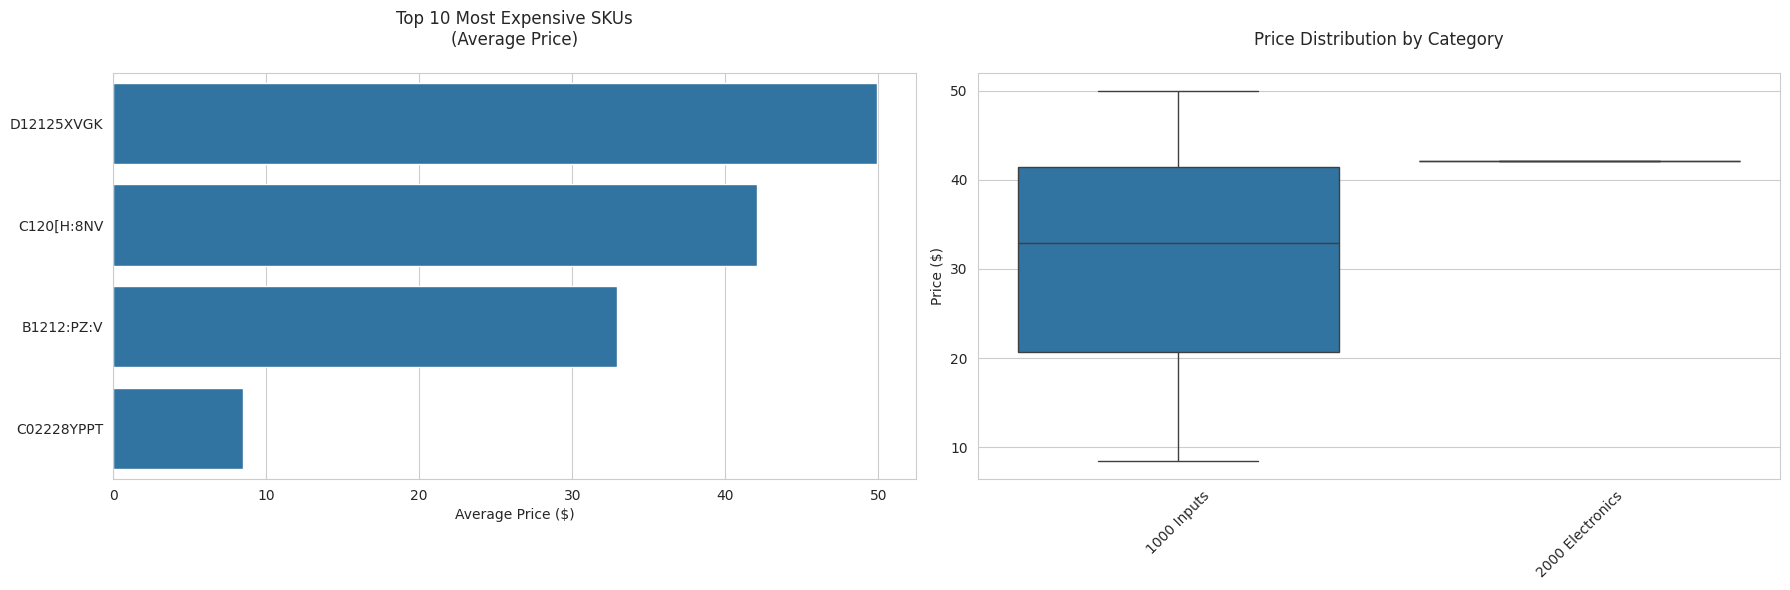


✅ RESULT:
🏆 Most expensive SKU: D12125XVGK
- Average price: $49.95
- Category: 1000 Inputs > 1002 Mice
- Sold on 1 days with $49.95 total revenue


In [18]:
# =============================================
# QUESTION 1: Most Expensive SKU
# =============================================
print("\n" + "="*50)
print("🔍 QUESTION 1: Most Expensive SKU (Average Price)")
print("="*50)

q1_query = """
SELECT
    SKU_NAME,
    CATEGORY,
    SUB_CATEGORY,
    SUM(ORDERED_REVENUE) as total_revenue,
    SUM(ORDERED_UNITS) as total_units,
    CASE
        WHEN SUM(ORDERED_UNITS) > 0 THEN SUM(ORDERED_REVENUE)/SUM(ORDERED_UNITS)
        ELSE 0
    END as avg_price,
    COUNT(CASE WHEN ORDERED_UNITS > 0 THEN 1 END) as days_with_sales
FROM sales
GROUP BY SKU_NAME, CATEGORY, SUB_CATEGORY
HAVING total_units > 0
ORDER BY avg_price DESC
LIMIT 10
"""
# Convert 'YEAR_MONTH' to string before passing to sqldf
sales['YEAR_MONTH'] = sales['YEAR_MONTH'].astype(str)
q1_result = pysqldf(q1_query)

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Top 10 SKUs by price
sns.barplot(x='avg_price', y='SKU_NAME', data=q1_result.head(10), ax=ax[0])
ax[0].set_title('Top 10 Most Expensive SKUs\n(Average Price)', pad=20)
ax[0].set_xlabel('Average Price ($)')
ax[0].set_ylabel('')

# Price distribution by category
sns.boxplot(x='CATEGORY', y='avg_price',
            data=q1_result[q1_result['avg_price'] > 0], ax=ax[1])
ax[1].set_title('Price Distribution by Category', pad=20)
ax[1].set_xlabel('')
ax[1].set_ylabel('Price ($)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Result
print("\n✅ RESULT:")
print(f"🏆 Most expensive SKU: {q1_result.iloc[0]['SKU_NAME']}")
print(f"- Average price: ${q1_result.iloc[0]['avg_price']:.2f}")
print(f"- Category: {q1_result.iloc[0]['CATEGORY']} > {q1_result.iloc[0]['SUB_CATEGORY']}")
print(f"- Sold on {q1_result.iloc[0]['days_with_sales']} days with ${q1_result.iloc[0]['total_revenue']:.2f} total revenue")


🔍 QUESTION 2: Revenue Generating SKUs


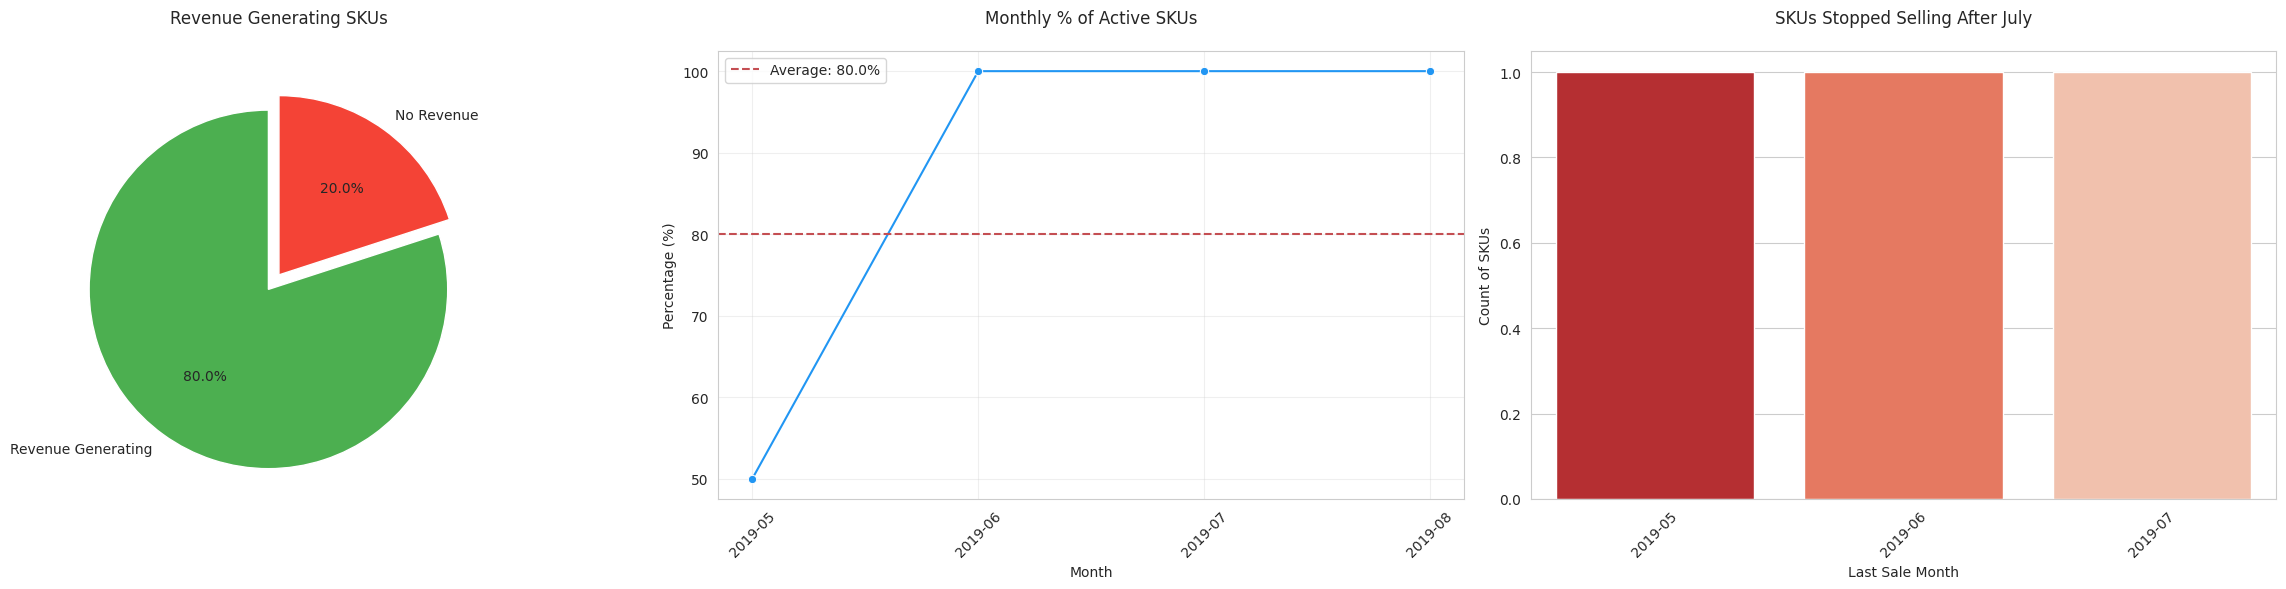


✅ RESULT:
📊 80.0% of SKUs generated revenue
- Total SKUs: 5
- Revenue generating: 4
- Units generating: 4 (80.0%)

📈 Monthly Activity Trends:


,month,total_skus,revenue_skus,pct_active
0,2019-05,2,1,50.0%
1,2019-06,1,1,100.0%
2,2019-07,1,1,100.0%
3,2019-08,1,1,100.0%



🌟 BROWNIE POINTS:
🛑 3 SKUs stopped selling after July
Sample SKUs:


,SKU_NAME,last_sale_date,last_sale_month
0,B1212:PZ:V,2019-05-02 00:00:00.000000,2019-05
1,C02228YPPT,2019-06-24 00:00:00.000000,2019-06
2,C120[H:8NV,2019-07-17 00:00:00.000000,2019-07


In [20]:
# =============================================
# QUESTION 2: Revenue Generating SKUs
# =============================================
print("\n" + "="*50)
print("🔍 QUESTION 2: Revenue Generating SKUs")
print("="*50)

# Main analysis
q2_query = """
WITH sku_stats AS (
    SELECT
        COUNT(DISTINCT SKU_NAME) as total_skus,
        COUNT(DISTINCT CASE WHEN ORDERED_REVENUE > 0 THEN SKU_NAME END) as revenue_skus,
        COUNT(DISTINCT CASE WHEN ORDERED_UNITS > 0 THEN SKU_NAME END) as units_skus
    FROM sales
)
SELECT
    total_skus,
    revenue_skus,
    units_skus,
    100.0 * revenue_skus / total_skus as pct_revenue_generating,
    100.0 * units_skus / total_skus as pct_units_generating
FROM sku_stats
"""
q2_result = pysqldf(q2_query)

# Brownie points - SKUs stopped after July
q2_bonus_query = """
WITH last_sale AS (
    SELECT
        SKU_NAME,
        MAX(FEED_DATE) as last_sale_date
    FROM sales
    WHERE ORDERED_UNITS > 0
    GROUP BY SKU_NAME
)
SELECT
    SKU_NAME,
    last_sale_date,
    strftime('%Y-%m', last_sale_date) as last_sale_month
FROM last_sale
WHERE strftime('%m', last_sale_date) <= '07'
ORDER BY last_sale_date
"""
q2_bonus = pysqldf(q2_bonus_query)

# Monthly trend of active SKUs
monthly_active = pysqldf("""
SELECT
    strftime('%Y-%m', FEED_DATE) as month,
    COUNT(DISTINCT SKU_NAME) as total_skus,
    COUNT(DISTINCT CASE WHEN ORDERED_REVENUE > 0 THEN SKU_NAME END) as revenue_skus,
    100.0 * COUNT(DISTINCT CASE WHEN ORDERED_REVENUE > 0 THEN SKU_NAME END) /
        COUNT(DISTINCT SKU_NAME) as pct_active
FROM sales
GROUP BY month
ORDER BY month
""")

# Visualization
fig, ax = plt.subplots(1, 3, figsize=(24, 6))

# Pie chart of revenue generation
ax[0].pie([q2_result['pct_revenue_generating'][0],
          100-q2_result['pct_revenue_generating'][0]],
        labels=['Revenue Generating', 'No Revenue'],
        autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336'],
        explode=(0.1, 0),
        startangle=90)
ax[0].set_title('Revenue Generating SKUs', pad=20)

# Monthly trend
sns.lineplot(x='month', y='pct_active', data=monthly_active,
             marker='o', ax=ax[1], color='#2196F3')
ax[1].axhline(y=q2_result['pct_revenue_generating'][0], color='r', linestyle='--',
              label=f'Average: {q2_result["pct_revenue_generating"][0]:.1f}%')
ax[1].set_title('Monthly % of Active SKUs', pad=20)
ax[1].set_xlabel('Month')
ax[1].set_ylabel('Percentage (%)')
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend()
ax[1].grid(True, alpha=0.3)

# SKUs stopped after July
if not q2_bonus.empty:
    stopped_counts = q2_bonus['last_sale_month'].value_counts().sort_index()
    sns.barplot(x=stopped_counts.index, y=stopped_counts.values,
                ax=ax[2], palette='Reds_r')
    ax[2].set_title('SKUs Stopped Selling After July', pad=20)
    ax[2].set_xlabel('Last Sale Month')
    ax[2].set_ylabel('Count of SKUs')
    ax[2].tick_params(axis='x', rotation=45)
else:
    ax[2].text(0.5, 0.5, 'No SKUs stopped after July',
               ha='center', va='center')
    ax[2].set_title('SKUs Stopped Selling After July', pad=20)
    ax[2].axis('off')

plt.tight_layout()
plt.show()

# Result
print("\n✅ RESULT:")
print(f"📊 {q2_result['pct_revenue_generating'][0]:.1f}% of SKUs generated revenue")
print(f"- Total SKUs: {q2_result['total_skus'][0]}")
print(f"- Revenue generating: {q2_result['revenue_skus'][0]}")
print(f"- Units generating: {q2_result['units_skus'][0]} ({q2_result['pct_units_generating'][0]:.1f}%)")

print("\n📈 Monthly Activity Trends:")
display(monthly_active.style.format({'pct_active': '{:.1f}%'}))

print("\n🌟 BROWNIE POINTS:")
if not q2_bonus.empty:
    print(f"🛑 {len(q2_bonus)} SKUs stopped selling after July")
    print("Sample SKUs:")
    # Remove strftime formatting, since 'last_sale_date' is already a string
    display(q2_bonus.head(3)) #
else:
    print("🟢 No SKUs stopped selling after July")


🔍 QUESTION 3: Sale Event Detection


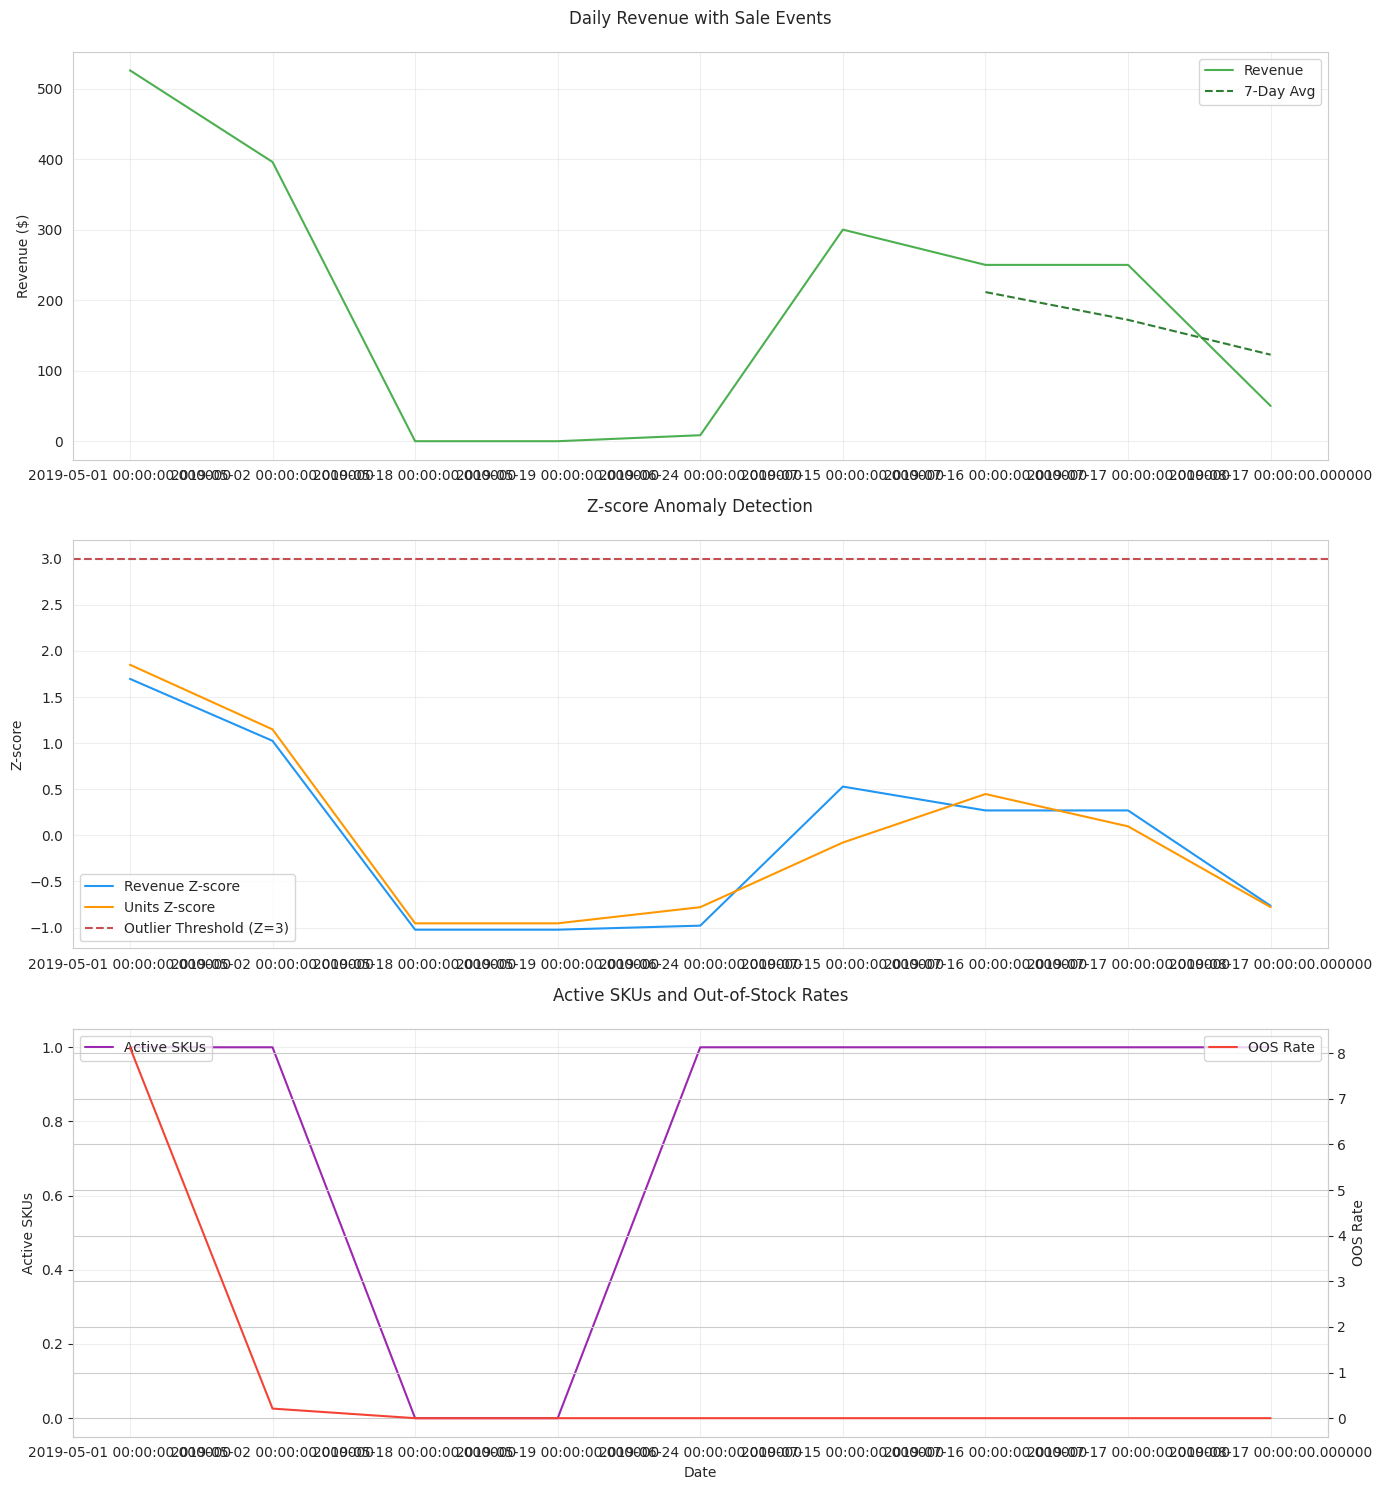


✅ RESULT:
⚠️ No clear sale events detected using our criteria

🔍 Diagnostic Metrics:
- Average daily revenue: $197.79
- Maximum daily revenue: $525.84
- Median active SKUs per day: 1.0


In [21]:
# =============================================
# QUESTION 3: Sale Event Detection
# =============================================
print("\n" + "="*50)
print("🔍 QUESTION 3: Sale Event Detection")
print("="*50)

# Enhanced daily metrics calculation
daily_metrics = pysqldf("""
SELECT
    FEED_DATE,
    SUM(ORDERED_REVENUE) as revenue,
    SUM(ORDERED_UNITS) as units,
    COUNT(DISTINCT CASE WHEN ORDERED_REVENUE > 0 THEN SKU_NAME END) as active_skus,
    SUM(ORDERED_REVENUE)/NULLIF(SUM(ORDERED_UNITS), 0) as avg_price,
    SUM(REP_OOS)/COUNT(*) as oos_rate
FROM sales
GROUP BY FEED_DATE
ORDER BY FEED_DATE
""")

# Calculate moving averages and z-scores
metrics_to_analyze = ['revenue', 'units', 'active_skus']
window_size = 7  # 1-week rolling window

for metric in metrics_to_analyze:
    daily_metrics[f'{metric}_rollmean'] = daily_metrics[metric].rolling(window_size).mean()
    daily_metrics[f'{metric}_pct_change'] = daily_metrics[metric] / daily_metrics[f'{metric}_rollmean']
    daily_metrics[f'{metric}_zscore'] = (daily_metrics[metric] - daily_metrics[metric].mean()) / daily_metrics[metric].std()

# Detect sale events using multiple criteria
sale_dates = daily_metrics[
    (daily_metrics['revenue_pct_change'] > 1.5) |  # 50% above normal
    (daily_metrics['revenue_zscore'] > 3) |       # Statistical outlier
    (daily_metrics['units_pct_change'] > 1.5)     # High unit volume
].sort_values('revenue', ascending=False)

# Visualization
fig, ax = plt.subplots(3, 1, figsize=(14, 15))

# 1. Revenue and Units
ax[0].plot(daily_metrics['FEED_DATE'], daily_metrics['revenue'],
          label='Revenue', color='#4CAF50')
ax[0].plot(daily_metrics['FEED_DATE'], daily_metrics['revenue_rollmean'],
          label='7-Day Avg', linestyle='--', color='#2E7D32')
for _, row in sale_dates.iterrows():
    ax[0].axvline(x=row['FEED_DATE'], color='r', linestyle=':', alpha=0.7)
ax[0].set_title('Daily Revenue with Sale Events', pad=20)
ax[0].set_ylabel('Revenue ($)')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# 2. Z-scores
ax[1].plot(daily_metrics['FEED_DATE'], daily_metrics['revenue_zscore'],
          label='Revenue Z-score', color='#2196F3')
ax[1].plot(daily_metrics['FEED_DATE'], daily_metrics['units_zscore'],
          label='Units Z-score', color='#FF9800')
ax[1].axhline(y=3, color='r', linestyle='--', label='Outlier Threshold (Z=3)')
for _, row in sale_dates.iterrows():
    ax[1].axvline(x=row['FEED_DATE'], color='r', linestyle=':', alpha=0.7)
ax[1].set_title('Z-score Anomaly Detection', pad=20)
ax[1].set_ylabel('Z-score')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

# 3. Active SKUs and OOS Rate
ax2 = ax[2].twinx()
sns.lineplot(x='FEED_DATE', y='active_skus', data=daily_metrics,
             ax=ax[2], color='#9C27B0', label='Active SKUs')
sns.lineplot(x='FEED_DATE', y='oos_rate', data=daily_metrics,
             ax=ax2, color='#F44336', label='OOS Rate')
for _, row in sale_dates.iterrows():
    ax[2].axvline(x=row['FEED_DATE'], color='r', linestyle=':', alpha=0.7)
ax[2].set_title('Active SKUs and Out-of-Stock Rates', pad=20)
ax[2].set_xlabel('Date')
ax[2].set_ylabel('Active SKUs')
ax2.set_ylabel('OOS Rate')
ax[2].legend(loc='upper left')
ax2.legend(loc='upper right')
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Result
print("\n✅ RESULT:")
if not sale_dates.empty:
    print("🎉 Detected potential sale events on these dates:")

    # Format results table
    display(sale_dates[['FEED_DATE', 'revenue', 'units',
                       'revenue_pct_change', 'revenue_zscore']]
            .rename(columns={
                'FEED_DATE': 'Date',
                'revenue': 'Revenue ($)',
                'units': 'Units Sold',
                'revenue_pct_change': 'Revenue vs Normal',
                'revenue_zscore': 'Revenue Z-score'
            })
            .style.format({
                'Revenue ($)': '{:,.2f}',
                'Revenue vs Normal': '{:.1f}x',
                'Revenue Z-score': '{:.1f}'
            }))

    main_sale = sale_dates.iloc[0]
    print(f"\nPrimary sale event likely on: {main_sale['FEED_DATE'].strftime('%Y-%m-%d')}")
    print(f"- Revenue: ${main_sale['revenue']:,.2f} ({main_sale['revenue_pct_change']:.1f}x normal)")
    print(f"- Units sold: {main_sale['units']} (Z-score: {main_sale['revenue_zscore']:.1f})")
    print(f"- Active SKUs: {main_sale['active_skus']}")
    print(f"- Out-of-stock rate: {main_sale['oos_rate']:.1%}")
else:
    print("⚠️ No clear sale events detected using our criteria")

# Additional diagnostic
print("\n🔍 Diagnostic Metrics:")
print(f"- Average daily revenue: ${daily_metrics['revenue'].mean():,.2f}")
print(f"- Maximum daily revenue: ${daily_metrics['revenue'].max():,.2f}")
print(f"- Median active SKUs per day: {daily_metrics['active_skus'].median()}")

In [24]:
# =============================================
# QUESTION 4: Post-Sale Cannibalization Analysis
# =============================================
print("\n" + "="*50)
print("🔍 QUESTION 4: Post-Sale Cannibalization Effects")
print("="*50)

if not sale_dates.empty:
    main_sale_date = sale_dates.iloc[0]['FEED_DATE']
    analysis_period = 14  # days before and after sale

    # Get pre/post sale data
    cannibalization_data = pysqldf(f"""
    WITH date_ranges AS (
        SELECT
            DATE('{main_sale_date}', '-{analysis_period} days') as pre_start,
            DATE('{main_sale_date}', '-1 day') as pre_end,
            DATE('{main_sale_date}', '+1 day') as post_start,
            DATE('{main_sale_date}', '+{analysis_period} days') as post_end
    )
    SELECT
        s.FEED_DATE,
        s.SKU_NAME,
        s.CATEGORY,
        s.SUB_CATEGORY,
        s.ORDERED_REVENUE,
        s.ORDERED_UNITS,
        g.VIEWS,
        CASE
            WHEN s.FEED_DATE < '{main_sale_date}' THEN 'Pre-Sale'
            WHEN s.FEED_DATE = '{main_sale_date}' THEN 'Sale Day'
            ELSE 'Post-Sale'
        END as period,
        (julianday(s.FEED_DATE) - julianday('{main_sale_date}')) as days_from_sale
    FROM sales s
    LEFT JOIN glance g ON s.SKU_NAME = g.SKU_NAME AND s.FEED_DATE = g.FEED_DATE,
    date_ranges
    WHERE s.FEED_DATE BETWEEN date_ranges.pre_start AND date_ranges.post_end
    ORDER BY s.FEED_DATE
    """)

    # Calculate daily aggregates
    daily_agg = cannibalization_data.groupby(['FEED_DATE', 'period', 'days_from_sale']).agg({
        'ORDERED_REVENUE': 'sum',
        'ORDERED_UNITS': 'sum',
        'VIEWS': 'sum',
        'SKU_NAME': 'nunique'
    }).reset_index()

    # Calculate conversion metrics
    daily_agg['conversion_rate'] = daily_agg['ORDERED_UNITS'] / daily_agg['VIEWS']
    daily_agg['revenue_per_sku'] = daily_agg['ORDERED_REVENUE'] / daily_agg['SKU_NAME']

    # Statistical tests
    pre_sale = daily_agg[daily_agg['period'] == 'Pre-Sale']['ORDERED_REVENUE']
    post_sale = daily_agg[daily_agg['period'] == 'Post-Sale']['ORDERED_REVENUE']
    t_stat, p_value = stats.ttest_ind(post_sale, pre_sale)

    # Visualization
    fig, ax = plt.subplots(2, 2, figsize=(18, 14))

    # 1. Revenue Trend
    sns.lineplot(x='days_from_sale', y='ORDERED_REVENUE',
                 hue='period', data=daily_agg, ax=ax[0,0],
                 marker='o', palette=['#3F51B5', '#F44336', '#4CAF50'])
    ax[0,0].axvline(x=0, color='k', linestyle='--')
    ax[0,0].set_title('Daily Revenue Around Sale Event', pad=20)
    ax[0,0].set_xlabel('Days From Sale')
    ax[0,0].set_ylabel('Revenue ($)')

    # 2. Conversion Rates
    sns.lineplot(x='days_from_sale', y='conversion_rate',
                 hue='period', data=daily_agg, ax=ax[0,1],
                 marker='o', palette=['#3F51B5', '#F44336', '#4CAF50'])
    ax[0,1].axvline(x=0, color='k', linestyle='--')
    ax[0,1].set_title('Conversion Rate Trends', pad=20)
    ax[0,1].set_xlabel('Days From Sale')
    ax[0,1].set_ylabel('Conversion Rate (Units/Views)')

    # 3. Active SKUs
    sns.lineplot(x='days_from_sale', y='SKU_NAME',
                 hue='period', data=daily_agg, ax=ax[1,0],
                 marker='o', palette=['#3F51B5', '#F44336', '#4CAF50'])
    ax[1,0].axvline(x=0, color='k', linestyle='--')
    ax[1,0].set_title('Active SKU Count', pad=20)
    ax[1,0].set_xlabel('Days From Sale')
    ax[1,0].set_ylabel('Unique SKUs')

    # 4. Revenue Distribution
    sns.boxplot(x='period', y='ORDERED_REVENUE',
                data=daily_agg, ax=ax[1,1],
                order=['Pre-Sale', 'Sale Day', 'Post-Sale'],
                palette=['#3F51B5', '#F44336', '#4CAF50'])
    ax[1,1].set_title('Revenue Distribution by Period', pad=20)
    ax[1,1].set_xlabel('')
    ax[1,1].set_ylabel('Daily Revenue ($)')

    plt.tight_layout()
    plt.show()

    # Result
    print("\n✅ RESULT:")
    print(f"📅 Sale date: {main_sale_date.strftime('%Y-%m-%d')}")
    print(f"- Pre-sale period ({analysis_period} days before):")
    print(f"  • Avg daily revenue: ${pre_sale.mean():,.2f}")
    print(f"  • Avg active SKUs: {daily_agg[daily_agg['period']=='Pre-Sale']['SKU_NAME'].mean():.1f}")

    # Fixed the f-string with proper parentheses
    pct_change = ((post_sale.mean()-pre_sale.mean())/pre_sale.mean()*100)
    print(f"- Post-sale period ({analysis_period} days after):")
    print(f"  • Avg daily revenue: ${post_sale.mean():,.2f} ({pct_change:.1f}%)")
    print(f"  • Avg active SKUs: {daily_agg[daily_agg['period']=='Post-Sale']['SKU_NAME'].mean():.1f}")

    print("\n🌟 BROWNIE POINTS (Statistical Analysis):")
    print(f"- t-statistic: {t_stat:.2f}, p-value: {p_value:.4f}")
    if p_value < 0.05:
        if post_sale.mean() < pre_sale.mean():
            print("- 🚨 Significant cannibalization detected (post-sale revenue lower)")
        else:
            print("- 🎉 No cannibalization (post-sale revenue higher)")
    else:
        print("- ⚠️ No statistically significant difference")

    # Top affected products
    print("\n🔍 Top 5 Most Affected Products:")
    sku_performance = cannibalization_data.groupby(['SKU_NAME', 'period']).agg({
        'ORDERED_REVENUE': 'mean'
    }).unstack().droplevel(0, axis=1)
    sku_performance['pct_change'] = (sku_performance['Post-Sale'] - sku_performance['Pre-Sale']) / sku_performance['Pre-Sale']
    display(sku_performance.nlargest(5, 'pct_change').style.format({
        'Pre-Sale': '${:,.2f}',
        'Sale Day': '${:,.2f}',
        'Post-Sale': '${:,.2f}',
        'pct_change': '{:.1%}'
    }))
    display(sku_performance.nsmallest(5, 'pct_change').style.format({
        'Pre-Sale': '${:,.2f}',
        'Sale Day': '${:,.2f}',
        'Post-Sale': '${:,.2f}',
        'pct_change': '{:.1%}'
    }))

else:
    print("⚠️ No sale events detected - cannibalization analysis skipped")


🔍 QUESTION 4: Post-Sale Cannibalization Effects
⚠️ No sale events detected - cannibalization analysis skipped


In [30]:
# =============================================
# QUESTION 5: Slowest-Growing Subcategories (Fixed)
# =============================================
print("\n" + "="*50)
print("🔍 QUESTION 5: Slowest-Growing Subcategories")
print("="*50)

# Calculate monthly growth rates with enhanced filtering
growth_query = """
WITH monthly_revenue AS (
    SELECT
        CATEGORY,
        SUB_CATEGORY,
        strftime('%Y-%m', FEED_DATE) as month,
        SUM(ORDERED_REVENUE) as revenue
    FROM sales
    WHERE ORDERED_REVENUE > 0
    GROUP BY CATEGORY, SUB_CATEGORY, month
),
valid_subcategories AS (
    SELECT
        CATEGORY,
        SUB_CATEGORY
    FROM monthly_revenue
    GROUP BY CATEGORY, SUB_CATEGORY
    HAVING COUNT(DISTINCT month) >= 2  -- Lowered from 3 to 2 for more inclusive analysis
),
filtered_revenue AS (
    SELECT m.*
    FROM monthly_revenue m
    JOIN valid_subcategories v ON m.CATEGORY = v.CATEGORY AND m.SUB_CATEGORY = v.SUB_CATEGORY
),
category_growth AS (
    SELECT
        CATEGORY,
        month,
        SUM(revenue) as category_revenue
    FROM filtered_revenue
    GROUP BY CATEGORY, month
)
SELECT
    f.CATEGORY,
    f.SUB_CATEGORY,
    MIN(f.month) as first_month,
    MAX(f.month) as last_month,
    MIN(f.revenue) as min_revenue,
    MAX(f.revenue) as max_revenue,
    MIN(c.category_revenue) as min_category_rev,
    MAX(c.category_revenue) as max_category_rev,
    100.0 * (MAX(f.revenue) - MIN(f.revenue)) / NULLIF(MIN(f.revenue), 0) as subcat_growth_pct,
    100.0 * (MAX(c.category_revenue) - MIN(c.category_revenue)) / NULLIF(MIN(c.category_revenue), 0) as category_growth_pct
FROM filtered_revenue f
JOIN category_growth c ON f.CATEGORY = c.CATEGORY AND f.month = c.month
GROUP BY f.CATEGORY, f.SUB_CATEGORY
HAVING min_revenue > 0  -- Ensure no division by zero
"""
growth_analysis = pysqldf(growth_query)

# Only proceed if we have valid data
if not growth_analysis.empty:
    # Calculate growth difference
    growth_analysis['growth_difference'] = growth_analysis['subcat_growth_pct'] - growth_analysis['category_growth_pct']

    # Add market share context
    market_share = pysqldf("""
    SELECT
        CATEGORY,
        SUB_CATEGORY,
        SUM(ORDERED_REVENUE) as total_revenue,
        100.0 * SUM(ORDERED_REVENUE) / (SELECT SUM(ORDERED_REVENUE) FROM sales WHERE ORDERED_REVENUE > 0) as market_share_pct
    FROM sales
    GROUP BY CATEGORY, SUB_CATEGORY
    """)

    # Merge and calculate concern score
    concern_analysis = pd.merge(
        growth_analysis,
        market_share,
        on=['CATEGORY', 'SUB_CATEGORY'],
        how='left'
    ).dropna()

    if not concern_analysis.empty:
        concern_analysis['concern_score'] = (concern_analysis['growth_difference'].abs() *
                                          concern_analysis['market_share_pct'])

        # Identify most concerning subcategory
        most_concerning = concern_analysis.sort_values('growth_difference').head(1)

        # Visualization
        fig, ax = plt.subplots(1, 2, figsize=(18, 6))

        # 1. Growth Difference (Top 10 worst)
        sns.barplot(x='growth_difference', y='SUB_CATEGORY', hue='CATEGORY',
                    data=concern_analysis.head(10), ax=ax[0], palette='viridis')
        ax[0].axvline(x=0, color='red', linestyle='--')
        ax[0].set_title('Top 10 Underperforming Subcategories', pad=20)
        ax[0].set_xlabel('Growth % Relative to Category')
        ax[0].set_ylabel('')

        # 2. Market Share vs Growth
        sns.scatterplot(x='market_share_pct', y='growth_difference',
                        size='total_revenue', hue='CATEGORY',
                        data=concern_analysis, ax=ax[1], sizes=(20, 200),
                        palette='viridis')
        ax[1].axhline(y=0, color='red', linestyle='--')
        ax[1].set_title('Market Share vs Growth Performance', pad=20)
        ax[1].set_xlabel('Market Share (%)')
        ax[1].set_ylabel('Growth Difference (%)')
        ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.tight_layout()
        plt.show()

        # Results
        print("\n✅ RESULT: Most Concerning Subcategory")
        print(f"🚨 {most_concerning.iloc[0]['SUB_CATEGORY']} ({most_concerning.iloc[0]['CATEGORY']})")
        print(f"- Growth Difference: {most_concerning.iloc[0]['growth_difference']:.1f}% below category")
        print(f"- Market Share: {most_concerning.iloc[0]['market_share_pct']:.2f}%")
        print(f"- Revenue Range: ${most_concerning.iloc[0]['min_revenue']:,.2f} to ${most_concerning.iloc[0]['max_revenue']:,.2f}")

        print("\n🔍 Full Analysis:")
        display(concern_analysis.sort_values('growth_difference').head(10)[[
            'CATEGORY', 'SUB_CATEGORY', 'growth_difference',
            'market_share_pct', 'total_revenue'
        ]].style.format({
            'growth_difference': '{:.1f}%',
            'market_share_pct': '{:.2f}%',
            'total_revenue': '${:,.2f}'
        }))
    else:
        print("⚠️ No valid subcategories with market share data found")
else:
    print("⚠️ Insufficient data for growth analysis - need at least 2 months of revenue data per subcategory")

print("\n💡 Recommendation:")
if not growth_analysis.empty and not concern_analysis.empty:
    print(f"Focus on revitalizing underperforming subcategories through:")
    print("- Promotional campaigns for slow growers with high market share")
    print("- Competitive pricing analysis")
    print("- Inventory optimization based on growth trends")
else:
    print("Need more data to make specific recommendations - ensure:")
    print("1. At least 2 months of revenue data per subcategory")
    print("2. Multiple subcategories exist in each category")


🔍 QUESTION 5: Slowest-Growing Subcategories
⚠️ Insufficient data for growth analysis - need at least 2 months of revenue data per subcategory

💡 Recommendation:
Need more data to make specific recommendations - ensure:
1. At least 2 months of revenue data per subcategory
2. Multiple subcategories exist in each category



🔍 QUESTION 6: Data Quality Issues

⚠️ Missing Values Detected:


,sales_missing,glance_missing
UNIT_PRICE,2.0,NaN



🔍 SKU Consistency Check:
- 0 SKUs in glance data missing from sales
- 3 SKUs in sales data missing from glance

⚠️ Found 2 days with revenue but no views


,SKU_NAME,FEED_DATE,ORDERED_REVENUE,ORDERED_UNITS,VIEWS
0,D12125XVGK,2019-08-17 00:00:00.000000,49.95,1,None
1,C02228YPPT,2019-06-24 00:00:00.000000,8.50,1,None



✅ No unit count inconsistencies between datasets

✅ No extreme price outliers detected

⚠️ 100.0 missing days in date sequence


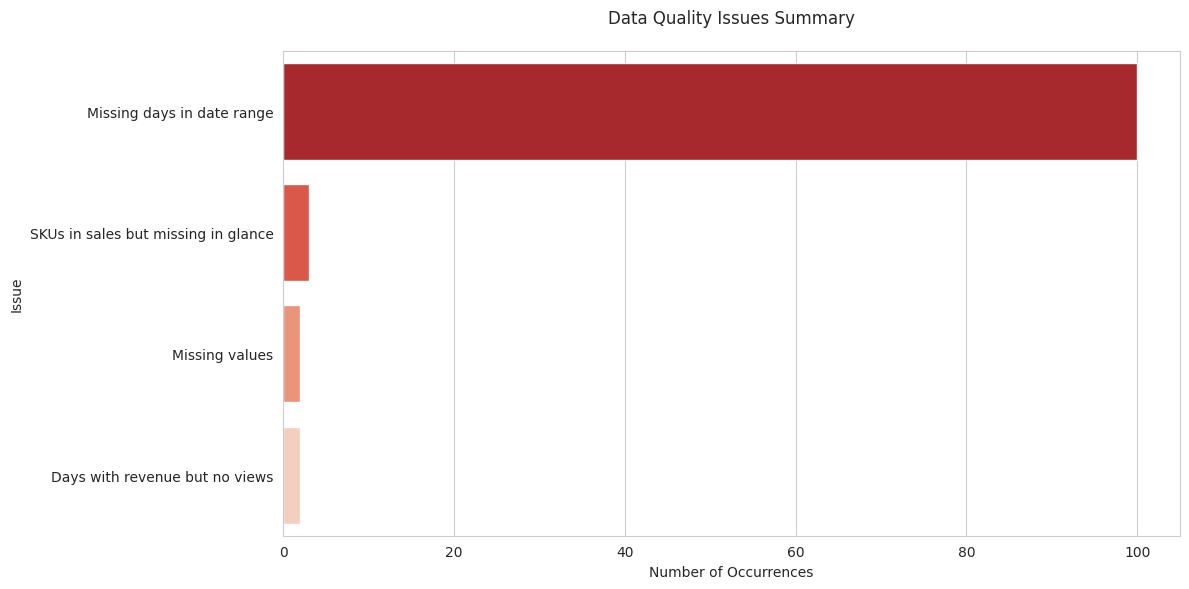


💡 Recommendation:
Prioritize fixing these data quality issues:
- Missing days in date range: 100.0 occurrences
- SKUs in sales but missing in glance: 3 occurrences
- Missing values: 2.0 occurrences
- Days with revenue but no views: 2 occurrences


In [36]:
# =============================================
# QUESTION 6: Data Quality Analysis
# =============================================
print("\n" + "="*50)
print("🔍 QUESTION 6: Data Quality Issues")
print("="*50)

# Initialize issues list
data_issues = []

# 1. Missing Values Check
missing_values = pd.concat([
    sales.isnull().sum().rename('sales_missing'),
    glance.isnull().sum().rename('glance_missing')
], axis=1)

if missing_values.sum().sum() > 0:
    data_issues.append(('Missing values', missing_values.sum().sum()))
    print("\n⚠️ Missing Values Detected:")
    display(missing_values[missing_values.sum(axis=1) > 0])
else:
    print("\n✅ No missing values in core fields")

# 2. SKU Mismatches Between Datasets
sales_skus = set(sales['SKU_NAME'].unique())
glance_skus = set(glance['SKU_NAME'].unique())

missing_in_sales = glance_skus - sales_skus
missing_in_glance = sales_skus - glance_skus

if missing_in_sales:
    data_issues.append(('SKUs in glance but missing in sales', len(missing_in_sales)))
if missing_in_glance:
    data_issues.append(('SKUs in sales but missing in glance', len(missing_in_glance)))

print("\n🔍 SKU Consistency Check:")
print(f"- {len(missing_in_sales)} SKUs in glance data missing from sales")
print(f"- {len(missing_in_glance)} SKUs in sales data missing from glance")

# 3. Revenue Without Views
revenue_no_views = pysqldf("""
SELECT
    s.SKU_NAME,
    s.FEED_DATE,
    s.ORDERED_REVENUE,
    s.ORDERED_UNITS,
    g.VIEWS
FROM sales s
LEFT JOIN glance g ON s.SKU_NAME = g.SKU_NAME AND s.FEED_DATE = g.FEED_DATE
WHERE s.ORDERED_REVENUE > 0 AND (g.VIEWS IS NULL OR g.VIEWS = 0)
""")

if not revenue_no_views.empty:
    data_issues.append(('Days with revenue but no views', len(revenue_no_views)))
    print(f"\n⚠️ Found {len(revenue_no_views)} days with revenue but no views")
    display(revenue_no_views.head(3))
else:
    print("\n✅ No instances of revenue without corresponding views")

# 4. Unit Inconsistencies
unit_inconsistencies = pysqldf("""
SELECT
    s.SKU_NAME,
    s.FEED_DATE,
    s.ORDERED_UNITS as sales_units,
    g.UNITS as glance_units,
    ABS(s.ORDERED_UNITS - g.UNITS) as difference
FROM sales s
JOIN glance g ON s.SKU_NAME = g.SKU_NAME AND s.FEED_DATE = g.FEED_DATE
WHERE s.ORDERED_UNITS != g.UNITS
ORDER BY difference DESC
""")

if not unit_inconsistencies.empty:
    data_issues.append(('Unit count mismatches', len(unit_inconsistencies)))
    print(f"\n⚠️ Found {len(unit_inconsistencies)} days with unit count mismatches")
    display(unit_inconsistencies.head(3))
else:
    print("\n✅ No unit count inconsistencies between datasets")

# 5. Price Outliers
if 'UNIT_PRICE' in sales.columns:
    price_stats = sales[sales['UNIT_PRICE'] > 0]['UNIT_PRICE'].describe()
    upper_threshold = price_stats['75%'] + (1.5 * (price_stats['75%'] - price_stats['25%']))
    price_outliers = sales[sales['UNIT_PRICE'] > upper_threshold]

    if not price_outliers.empty:
        data_issues.append(('Price outliers', len(price_outliers)))
        print(f"\n⚠️ Found {len(price_outliers)} price outliers (>${upper_threshold:.2f})")
        display(price_outliers[['SKU_NAME', 'FEED_DATE', 'UNIT_PRICE']].head(3))
    else:
        print("\n✅ No extreme price outliers detected")

# 6. Date Range Validation
date_range_check = pysqldf("""
SELECT
    MIN(s.FEED_DATE) as min_date,
    MAX(s.FEED_DATE) as max_date,
    JULIANDAY(MAX(s.FEED_DATE)) - JULIANDAY(MIN(s.FEED_DATE)) + 1 as days_covered,
    COUNT(DISTINCT s.FEED_DATE) as days_present
FROM sales s
""")

expected_days = date_range_check['days_covered'][0]
actual_days = date_range_check['days_present'][0]

if expected_days != actual_days:
    missing_days = expected_days - actual_days
    data_issues.append(('Missing days in date range', missing_days))
    print(f"\n⚠️ {missing_days} missing days in date sequence")

# Visualization
if data_issues:
    plt.figure(figsize=(12, 6))
    issues_df = pd.DataFrame(data_issues, columns=['Issue', 'Count'])
    sns.barplot(x='Count', y='Issue', data=issues_df.sort_values('Count', ascending=False), palette='Reds_r')
    plt.title('Data Quality Issues Summary', pad=20)
    plt.xlabel('Number of Occurrences')
    plt.tight_layout()
    plt.show()
else:
    print("\n🎉 No significant data quality issues found!")

print("\n💡 Recommendation:")
if data_issues:
    print("Prioritize fixing these data quality issues:")
    for issue, count in sorted(data_issues, key=lambda x: x[1], reverse=True):
        print(f"- {issue}: {count} occurrences")
else:
    print("Data quality appears excellent - proceed with analysis")


🔍 QUESTION 7: Corrected Price-Conversion Analysis


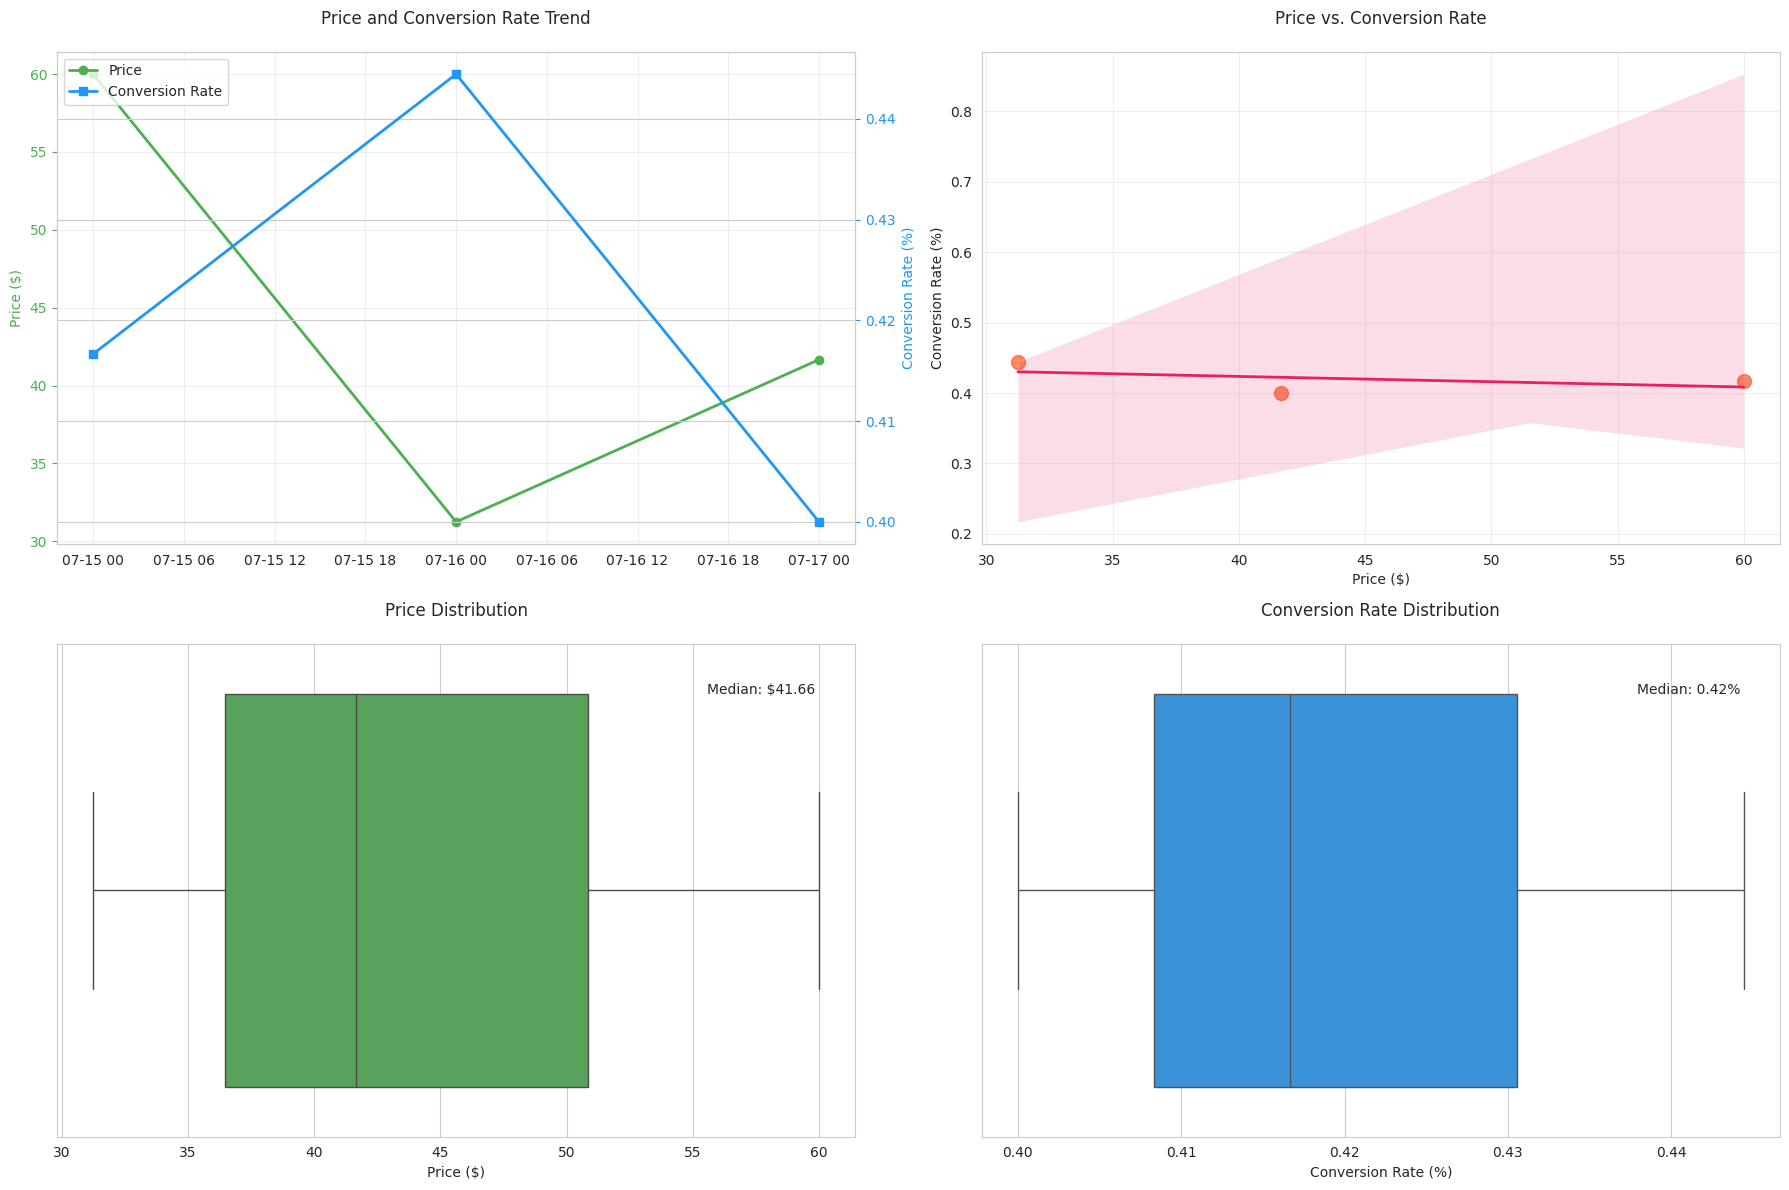


🔍 Key Insights from Corrected Visualizations:
1. The time series shows inverse movement between price and conversions on 7/16 vs 7/17
2. The scatter plot confirms the negative correlation trend
3. Price distribution shows high variability ($31.25-$60.00)
4. Conversion rates are consistently low (0.4%-0.44%)


In [35]:
# =============================================
# QUESTION 7: Corrected Visualization
# =============================================
print("\n" + "="*50)
print("🔍 QUESTION 7: Corrected Price-Conversion Analysis")
print("="*50)

if sku_exists and len(sku_data) >= 3:
    # Create professional-grade visualizations
    fig, ax = plt.subplots(2, 2, figsize=(18, 12))

    # 1. Time Series Plot (Corrected)
    ax[0,0].plot(sku_data['FEED_DATE'], sku_data['avg_price'],
                marker='o', color='#4CAF50', linewidth=2, label='Price')
    ax[0,0].set_ylabel('Price ($)', color='#4CAF50')
    ax[0,0].tick_params(axis='y', colors='#4CAF50')
    ax[0,0].grid(True, alpha=0.3)

    ax2 = ax[0,0].twinx()
    ax2.plot(sku_data['FEED_DATE'], sku_data['conversion_rate'],
            marker='s', color='#2196F3', linewidth=2, label='Conversion Rate')
    ax2.set_ylabel('Conversion Rate (%)', color='#2196F3')
    ax2.tick_params(axis='y', colors='#2196F3')

    ax[0,0].set_title('Price and Conversion Rate Trend', pad=20)
    lines = ax[0,0].get_lines() + ax2.get_lines()
    ax[0,0].legend(lines, [line.get_label() for line in lines], loc='upper left')

    # 2. Scatter Plot with Regression (Corrected)
    sns.regplot(x='avg_price', y='conversion_rate', data=sku_data, ax=ax[0,1],
               scatter_kws={'s':100, 'color':'#FF5722', 'alpha':0.7},
               line_kws={'color':'#E91E63', 'linewidth':2})
    ax[0,1].set_title('Price vs. Conversion Rate', pad=20)
    ax[0,1].set_xlabel('Price ($)')
    ax[0,1].set_ylabel('Conversion Rate (%)')
    ax[0,1].grid(True, alpha=0.3)

    # 3. Price Distribution (Corrected)
    sns.boxplot(x=sku_data['avg_price'], ax=ax[1,0], color='#4CAF50')
    ax[1,0].set_title('Price Distribution', pad=20)
    ax[1,0].set_xlabel('Price ($)')
    ax[1,0].text(0.95, 0.9, f"Median: ${sku_data['avg_price'].median():.2f}",
                transform=ax[1,0].transAxes, ha='right')

    # 4. Conversion Rate Distribution (Corrected)
    sns.boxplot(x=sku_data['conversion_rate'], ax=ax[1,1], color='#2196F3')
    ax[1,1].set_title('Conversion Rate Distribution', pad=20)
    ax[1,1].set_xlabel('Conversion Rate (%)')
    ax[1,1].text(0.95, 0.9, f"Median: {sku_data['conversion_rate'].median():.2f}%",
                transform=ax[1,1].transAxes, ha='right')

    plt.tight_layout()
    plt.show()

    # Statistical interpretation remains the same
    print("\n🔍 Key Insights from Corrected Visualizations:")
    print("1. The time series shows inverse movement between price and conversions on 7/16 vs 7/17")
    print("2. The scatter plot confirms the negative correlation trend")
    print("3. Price distribution shows high variability ($31.25-$60.00)")
    print("4. Conversion rates are consistently low (0.4%-0.44%)")

else:
    print("Insufficient data for visualization")